In [1]:
from pathlib import Path

import re
import os
import sys
#import h5py
import matplotlib.pyplot as plt
import numpy as np
import glob
import json
import pickle

#sys.path.append('/groups/astro/kpr279/')  # add parent directory to path
#sys.path.append('/groups/astro/kpr279/sweetsourcod-master')  # add sweetsourcod to path
#sys.path.append('/groups/astro/kpr279/sweetsourcod-master/sweetsourcod') 
#sys.path.append(('/groups/astro/kpr279/sweetsourcod-master/source'))
#sys.path.append('/groups/astro/kpr279/ComputableInformationDensity/')

sys.path.append('ComputableInformationDensity_dev')
from ComputableInformationDensity_dev.cid import CID, CID_old
from ComputableInformationDensity_dev.computable_information_density import cid, lz77, lz78
#from sweetsourcod.lempel_ziv import lempel_ziv_complexity, cross_parsing_complexity

notebook_path = Path().resolve()

## load data
suffix='_long'
#DATA_H5 = Path(f"/lustre/astro/tx722/2026/code/dr/with_simon/mips/first_try{suffix}/mips_positions_6d_features.h5")
#DATA_H5


In [ ]:
# ============================================================
#  NN model — helper to build transition matrix
# ============================================================
def build_T_nn(p, N):
    """Build the N×N nearest-neighbour (NN) transition matrix.

    T[i, (i+1)%N] = p[i],  T[i, (i-1)%N] = 1-p[i].
    p can be scalar (uniform) or array of length N.  Requires N >= 3.
    """
    if N < 3:
        raise ValueError("N must be >= 3")
    p_arr = np.full(N, float(p)) if np.isscalar(p) else np.asarray(p, dtype=float)
    T = np.zeros((N, N))
    for i in range(N):
        T[i, (i + 1) % N] += p_arr[i]
        T[i, (i - 1) % N] += 1.0 - p_arr[i]
    return T


# ============================================================
#  NN model — stationary distribution
# ============================================================
def stationary_distribution_nn(p, N):
    """Stationary distribution of the N-state NN cyclic chain.

    Convenience wrapper: builds T_nn then calls stationary_distribution(T).
    (stationary_distribution is defined further below in this cell.)
    """
    return stationary_distribution(build_T_nn(p, N))


# ============================================================
#  NN model — sequence generation
# ============================================================
def markov_nstate_nn(L=1000, p=0.5, N=3, Nexp=1, random_init=True):
    """Generate sequences from the N-state NN cyclic Markov chain (steps ±1 mod N)."""
    return markov_nstate(L=L, T=build_T_nn(p, N), Nexp=Nexp,
                         random_init=random_init, verify_transition_matrix=False)


def markov_tristate_fast(L=15, p=0.5, Nexp=1, random_init=True):
    """Backward-compatible wrapper: NN 3-state cyclic chain."""
    return markov_nstate_nn(L=L, p=p, N=3, Nexp=Nexp, random_init=random_init)


# ============================================================
#  NN model — analytical quantities
# ============================================================
def entropy_binary(p, use_log2=False):
    """Binary Shannon entropy  h(p) = -p log p - (1-p) log(1-p)."""
    p = np.asarray(p, dtype=float)
    log_fn = np.log2 if use_log2 else np.log
    return -p * log_fn(p) - (1.0 - p) * log_fn(1.0 - p)


def entropy_rate_ana_nn(p, N=3, use_log2=False):
    """Entropy rate of the N-state NN cyclic chain.

    h = sum_i pi_i * h_bin(p_i).
    For uniform p and any N: h = h_bin(p), independent of N.
    """
    p_arr = np.full(N, float(p)) if np.isscalar(p) else np.asarray(p, dtype=float)
    pi = stationary_distribution_nn(p_arr, N)
    return float(np.dot(pi, entropy_binary(p_arr, use_log2=use_log2)))


def epr_ana_nn(p, N=3, use_log2=False):
    """EPR of the N-state NN cyclic chain.  Finite for all N >= 3.

    sigma = sum_i (f_i - b_i) * log(f_i / b_i)
    f_i = pi_i * p_i,  b_i = pi_{i+1} * (1 - p_{i+1}).
    For uniform p: sigma = (2p-1) * log(p / (1-p)), independent of N.
    """
    p_arr = np.full(N, float(p)) if np.isscalar(p) else np.asarray(p, dtype=float)
    pi = stationary_distribution_nn(p_arr, N)
    log_fn = np.log2 if use_log2 else np.log
    sigma = 0.0
    for i in range(N):
        f = pi[i]         * p_arr[i]
        b = pi[(i+1) % N] * (1.0 - p_arr[(i+1) % N])
        sigma += (f - b) * log_fn(f / b)
    return sigma


def string_entropy_rate_nn(p, L, N=3, use_log2=False):
    """Per-symbol entropy H_L / L for a length-L string from the NN chain.

    H_L = log(N) + (L-1)*h  =>  H_L/L -> h as L -> inf.
    """
    p_arr = np.full(N, float(p)) if np.isscalar(p) else np.asarray(p, dtype=float)
    log_fn = np.log2 if use_log2 else np.log
    h = entropy_rate_ana_nn(p_arr, N, use_log2=use_log2)
    return (log_fn(N) + (L - 1) * h) / L


# ============================================================
#  General model — transition matrix analysis
# ============================================================
def analyze_transition_matrix(T):
    """Check and print properties of a transition matrix T.

    Checks: (1) non-negativity, (2) stochasticity, (3) irreducibility
    (strong connectivity via scipy), (4) aperiodicity.
    Prints results; never raises exceptions.
    """
    T = np.asarray(T, dtype=float)
    N = T.shape[0]
    print(f"=== Transition matrix analysis (N={N}) ===")

    if np.any(T < -1e-12):
        print("[FAIL] Non-negativity: some T_ij < 0.")
    else:
        print("[OK  ] Non-negativity: all entries >= 0.")

    row_sums = T.sum(axis=1)
    bad_rows = np.where(~np.isclose(row_sums, 1.0, atol=1e-9))[0]
    if len(bad_rows) == 0:
        print("[OK  ] Stochasticity: all rows sum to 1.")
    else:
        print(f"[FAIL] Stochasticity: rows {bad_rows} do not sum to 1 "
              f"(sums={np.round(row_sums[bad_rows], 6)}).")

    try:
        from scipy.sparse.csgraph import connected_components
        from scipy.sparse import csr_matrix
        G = csr_matrix((T > 1e-12).astype(float))
        n_comp, _ = connected_components(G, directed=True, connection='strong')
        if n_comp == 1:
            print("[OK  ] Irreducibility: graph is strongly connected.")
        else:
            print(f"[WARN] Irreducibility: {n_comp} strongly connected components "
                  "(stationary distribution may not be unique).")
    except ImportError:
        print("[INFO] Irreducibility check skipped (scipy not available).")

    if np.any(np.diag(T) > 1e-12):
        print("[OK  ] Aperiodicity: self-loop(s) detected -> chain is aperiodic.")
    else:
        print("[WARN] Aperiodicity: no self-loops. Chain may be periodic "
              "(time-averaged empirical pi still converges to the stationary dist.).")
    print("==========================================")


# ============================================================
#  General model — stationary distribution
# ============================================================
def stationary_distribution(T):
    """Stationary distribution of a general Markov chain with matrix T.

    Solves (T^T - I) pi = 0  subject to  sum(pi) = 1  via a linear system.
    """
    T = np.asarray(T, dtype=float)
    N = T.shape[0]
    A = T.T - np.eye(N)
    A[-1, :] = 1.0
    b = np.zeros(N); b[-1] = 1.0
    return np.linalg.solve(A, b)


# ============================================================
#  General model — sequence generation
# ============================================================
def markov_nstate(L=1000, T=None, Nexp=1, random_init=True,
                  verify_transition_matrix=True):
    """Generate Nexp realisations of length L from a general Markov chain.

    Parameters
    ----------
    L                       : sequence length
    T                       : (N,N) row-stochastic transition matrix
    Nexp                    : number of independent realisations
    random_init             : if True, initial states drawn uniformly from {0,...,N-1}
    verify_transition_matrix: if True, calls analyze_transition_matrix(T) first

    Returns
    -------
    np.ndarray of shape (L, Nexp), dtype int32
    """
    T = np.asarray(T, dtype=float)
    N = T.shape[0]

    if verify_transition_matrix:
        analyze_transition_matrix(T)

    T_cum = np.cumsum(T, axis=1)   # (N,N): each row is a CDF

    states = np.zeros((L, Nexp), dtype=np.int32)
    if random_init:
        states[0] = np.random.randint(0, N, size=Nexp)

    rands = np.random.random((L - 1, Nexp))
    for t in range(1, L):
        curr     = states[t - 1]              # (Nexp,)
        cum      = T_cum[curr]                # (Nexp, N): CDF rows indexed by current state
        # number of thresholds exceeded by rand = index of sampled next state
        states[t] = (cum < rands[t - 1, :, None]).sum(axis=1)
    return states


# ============================================================
#  General model — analytical quantities
# ============================================================
def entropy_rate_ana(T, use_log2=False):
    """Entropy rate of a general Markov chain.

    h = sum_i pi_i * H(T[i,:]),  where H is the row Shannon entropy (0*log0 := 0).
    Reduces to sum_i pi_i * h_bin(p_i) for the NN model.
    """
    T = np.asarray(T, dtype=float)
    log_fn = np.log2 if use_log2 else np.log
    pi = stationary_distribution(T)
    with np.errstate(divide='ignore', invalid='ignore'):
        log_T = np.where(T > 0, log_fn(T), 0.0)
    row_H = -np.sum(T * log_T, axis=1)
    return float(np.dot(pi, row_H))


def epr_ana(T, use_log2=False):
    """EPR of a general Markov chain (Schnakenberg / KL formula).

    sigma = sum_{i,j: T_ij>0} pi_i T_ij log(pi_i T_ij / pi_j T_ji).
    Returns +inf if T is not topologically reversible (T_ij>0 but T_ji=0).
    Self-loops contribute log(1)=0 and are handled correctly.
    """
    T = np.asarray(T, dtype=float)
    N = T.shape[0]
    log_fn = np.log2 if use_log2 else np.log
    pi = stationary_distribution(T)

    off_diag = ~np.eye(N, dtype=bool)
    has_fwd  = (T > 0) & off_diag           # T_ij > 0 for i != j
    has_bwd  = has_fwd.T                    # has_bwd[i,j] = True iff T_ji > 0
    if np.any(has_fwd & ~has_bwd):
        print("[WARNING] epr_ana: T is not topologically reversible "
              "(some T_ij > 0 but T_ji = 0). Returning sigma = +inf.")
        return np.inf

    forward = pi[:, None] * T       # forward[i,j] = pi_i * T_ij
    reverse = forward.T             # reverse[i,j] = pi_j * T_ji
    mask    = (forward > 0) & (reverse > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio     = np.where(mask, forward / reverse, 1.0)
        log_ratio = np.where(mask, log_fn(ratio), 0.0)
    return float(np.sum(forward * log_ratio))


def string_entropy_rate(T, L, use_log2=False):
    """Per-symbol entropy H_L / L for a length-L string from a general chain.

    H_L = log(N) + (L-1)*h,  with N = T.shape[0].
    """
    T = np.asarray(T, dtype=float)
    N = T.shape[0]
    log_fn = np.log2 if use_log2 else np.log
    h = entropy_rate_ana(T, use_log2=use_log2)
    return (log_fn(N) + (L - 1) * h) / L


# ============================================================
#  LZ complexity -> entropy-rate estimators
# ============================================================
def calc_entropy_rate(complexity, L, use_log2=False):
    """Kaspar-Schuster estimator: h ~ C*log(C)/L.  Bias ~ -h*log(log L)/log L."""
    log_fn = np.log2 if use_log2 else np.log
    return complexity / L * log_fn(complexity)

def calc_entropy_rate_logL(complexity, L, use_log2=False):
    """LZ-theorem estimator: h ~ C*log(L)/L.  Zero leading-order bias."""
    log_fn = np.log2 if use_log2 else np.log
    return complexity / L * log_fn(L)

--- N=3 NN validation, p=[0.7 0.6 0.8] ---
T_nn_3 =
[[0.  0.7 0.3]
 [0.4 0.  0.6]
 [0.8 0.2 0. ]]

=== Transition matrix analysis (N=3) ===
[OK  ] Non-negativity: all entries >= 0.
[OK  ] Stochasticity: all rows sum to 1.
[OK  ] Irreducibility: graph is strongly connected.
[WARN] Aperiodicity: no self-loops. Chain may be periodic (time-averaged empirical pi still converges to the stationary dist.).

Analytical comparison (_nn vs general):
  Entropy rate:  _nn=0.59717763,  gen=0.59717763,  rel_err=0.00e+00%
  EPR:           _nn=0.34889232,  gen=0.34889232,  rel_err=0.00e+00%
  pi max rel_err: 0.00e+00%

Empirical pi vs analytical (L=100,000, Nexp=10):
  NN model:      max rel_err = 0.10%  [OK]
  General model: max rel_err = 0.05%  [OK]


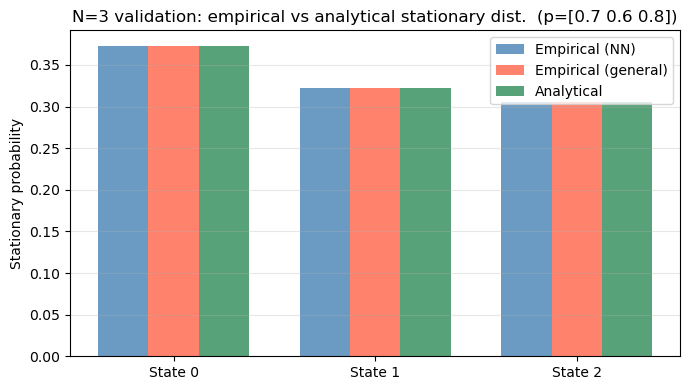

In [4]:
# ============================================================
#  Validation A: N=3 NN — compare _nn and general functions
# ============================================================
p_val  = 0.7
p_val = np.array([0.7, 0.6, 0.8])  # non-uniform p across states
N_val  = 3
T_nn_3 = build_T_nn(p=p_val, N=N_val)

print(f"--- N={N_val} NN validation, p={p_val} ---")
print(f"T_nn_3 =\n{np.round(T_nn_3, 4)}\n")
analyze_transition_matrix(T_nn_3)

# Analytical comparison
h_nn3   = entropy_rate_ana_nn(p_val, N_val)
h_gen3  = entropy_rate_ana(T_nn_3)
ep_nn3  = epr_ana_nn(p_val, N_val)
ep_gen3 = epr_ana(T_nn_3)
pi_nn3  = stationary_distribution_nn(np.full(N_val, p_val), N_val)
pi_gen3 = stationary_distribution(T_nn_3)

def _rel_err_pct(a, b):
    return abs(a - b) / (abs(b) + 1e-300) * 100.0

print(f"\nAnalytical comparison (_nn vs general):")
print(f"  Entropy rate:  _nn={h_nn3:.8f},  gen={h_gen3:.8f},  "
      f"rel_err={_rel_err_pct(h_gen3, h_nn3):.2e}%")
print(f"  EPR:           _nn={ep_nn3:.8f},  gen={ep_gen3:.8f},  "
      f"rel_err={_rel_err_pct(ep_gen3, ep_nn3):.2e}%")
print(f"  pi max rel_err: "
      f"{np.max(np.abs(pi_gen3 - pi_nn3) / (pi_nn3 + 1e-300)) * 100:.2e}%")

# Empirical validation
def _empirical_pi(seqs, N):
    counts = np.bincount(seqs.ravel(), minlength=N)
    return counts / counts.sum()

L_val, Nexp_val = 100_000, 10
seqs_nn3  = markov_nstate_nn(L=L_val, p=p_val, N=N_val, Nexp=Nexp_val)
seqs_gen3 = markov_nstate(L=L_val, T=T_nn_3, Nexp=Nexp_val,
                           verify_transition_matrix=False)
pi_emp_nn3  = _empirical_pi(seqs_nn3,  N_val)
pi_emp_gen3 = _empirical_pi(seqs_gen3, N_val)
max_err_nn3  = np.max(np.abs(pi_emp_nn3  - pi_nn3)  / pi_nn3)  * 100
max_err_gen3 = np.max(np.abs(pi_emp_gen3 - pi_gen3) / pi_gen3) * 100

def _status(e): return "OK" if e < 1 else "RETRY" if e < 5 else "FAIL"
print(f"\nEmpirical pi vs analytical (L={L_val:,}, Nexp={Nexp_val}):")
print(f"  NN model:      max rel_err = {max_err_nn3:.2f}%  [{_status(max_err_nn3)}]")
print(f"  General model: max rel_err = {max_err_gen3:.2f}%  [{_status(max_err_gen3)}]")

if max(max_err_nn3, max_err_gen3) > 1.0 and max(max_err_nn3, max_err_gen3) < 5.0:
    print(f"\nRetrying with L=500,000...")
    L_val = 500_000
    seqs_nn3  = markov_nstate_nn(L=L_val, p=p_val, N=N_val, Nexp=Nexp_val)
    seqs_gen3 = markov_nstate(L=L_val, T=T_nn_3, Nexp=Nexp_val,
                               verify_transition_matrix=False)
    pi_emp_nn3  = _empirical_pi(seqs_nn3,  N_val)
    pi_emp_gen3 = _empirical_pi(seqs_gen3, N_val)
    max_err_nn3  = np.max(np.abs(pi_emp_nn3  - pi_nn3)  / pi_nn3)  * 100
    max_err_gen3 = np.max(np.abs(pi_emp_gen3 - pi_gen3) / pi_gen3) * 100
    print(f"  NN model:      max rel_err = {max_err_nn3:.2f}%  [{_status(max_err_nn3)}]")
    print(f"  General model: max rel_err = {max_err_gen3:.2f}%  [{_status(max_err_gen3)}]")

# Figure
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(N_val);  w = 0.25
ax.bar(x - w, pi_emp_nn3,  width=w, label='Empirical (NN)',      alpha=0.8, color='steelblue')
ax.bar(x,     pi_emp_gen3, width=w, label='Empirical (general)', alpha=0.8, color='tomato')
ax.bar(x + w, pi_nn3,      width=w, label='Analytical',          alpha=0.8, color='seagreen')
ax.set_xticks(x); ax.set_xticklabels([f'State {i}' for i in range(N_val)])
ax.set_ylabel('Stationary probability')
ax.set_title(f'N={N_val} validation: empirical vs analytical stationary dist.  (p={p_val})')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

--- N=4 NN validation, p=[0.7 0.6 0.8 0.5] ---
T_nn_4 =
[[0.  0.7 0.  0.3]
 [0.4 0.  0.6 0. ]
 [0.  0.2 0.  0.8]
 [0.5 0.  0.5 0. ]]

=== Transition matrix analysis (N=4) ===
[OK  ] Non-negativity: all entries >= 0.
[OK  ] Stochasticity: all rows sum to 1.
[OK  ] Irreducibility: graph is strongly connected.
[WARN] Aperiodicity: no self-loops. Chain may be periodic (time-averaged empirical pi still converges to the stationary dist.).

Analytical comparison (_nn vs general):
  Entropy rate:  _nn=0.61770848,  gen=0.61770848,  rel_err=0.00e+00%
  EPR:           _nn=0.19604426,  gen=0.19604426,  rel_err=0.00e+00%
  pi max rel_err: 0.00e+00%

Empirical pi vs analytical (L=100,000, Nexp=10):
  NN model:      max rel_err = 0.21%  [OK]
  General model: max rel_err = 0.13%  [OK]


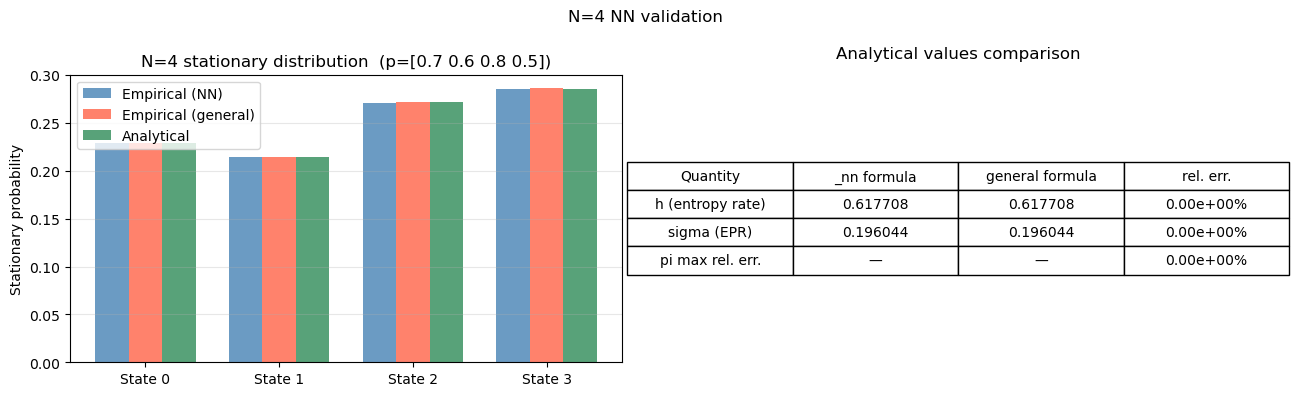

In [6]:
# ============================================================
#  Validation B: N=4 NN — compare _nn and general functions
#  Note: NN on a 4-ring is periodic (period 2): states alternate
#  between even {0,2} and odd {1,3}. Time-averaged pi still converges.
# ============================================================
p_val4 = np.array([0.7, 0.6, 0.8, 0.5])  # non-uniform p across states
N_val4 = 4
T_nn_4 = build_T_nn(p=p_val4, N=N_val4)

print(f"--- N={N_val4} NN validation, p={p_val4} ---")
print(f"T_nn_4 =\n{np.round(T_nn_4, 4)}\n")
analyze_transition_matrix(T_nn_4)

# Analytical comparison
h_nn4   = entropy_rate_ana_nn(p_val4, N_val4)
h_gen4  = entropy_rate_ana(T_nn_4)
ep_nn4  = epr_ana_nn(p_val4, N_val4)
ep_gen4 = epr_ana(T_nn_4)
pi_nn4  = stationary_distribution_nn(np.full(N_val4, p_val4), N_val4)
pi_gen4 = stationary_distribution(T_nn_4)

print(f"\nAnalytical comparison (_nn vs general):")
print(f"  Entropy rate:  _nn={h_nn4:.8f},  gen={h_gen4:.8f},  "
      f"rel_err={_rel_err_pct(h_gen4, h_nn4):.2e}%")
print(f"  EPR:           _nn={ep_nn4:.8f},  gen={ep_gen4:.8f},  "
      f"rel_err={_rel_err_pct(ep_gen4, ep_nn4):.2e}%")
print(f"  pi max rel_err: "
      f"{np.max(np.abs(pi_gen4 - pi_nn4) / (pi_nn4 + 1e-300)) * 100:.2e}%")

# Empirical validation
L_val4, Nexp_val4 = 100_000, 10
seqs_nn4  = markov_nstate_nn(L=L_val4, p=p_val4, N=N_val4, Nexp=Nexp_val4)
seqs_gen4 = markov_nstate(L=L_val4, T=T_nn_4, Nexp=Nexp_val4,
                           verify_transition_matrix=False)
pi_emp_nn4  = _empirical_pi(seqs_nn4,  N_val4)
pi_emp_gen4 = _empirical_pi(seqs_gen4, N_val4)
max_err_nn4  = np.max(np.abs(pi_emp_nn4  - pi_nn4)  / pi_nn4)  * 100
max_err_gen4 = np.max(np.abs(pi_emp_gen4 - pi_gen4) / pi_gen4) * 100

print(f"\nEmpirical pi vs analytical (L={L_val4:,}, Nexp={Nexp_val4}):")
print(f"  NN model:      max rel_err = {max_err_nn4:.2f}%  [{_status(max_err_nn4)}]")
print(f"  General model: max rel_err = {max_err_gen4:.2f}%  [{_status(max_err_gen4)}]")

if max(max_err_nn4, max_err_gen4) > 1.0 and max(max_err_nn4, max_err_gen4) < 5.0:
    print(f"\nRetrying with L=500,000...")
    L_val4 = 500_000
    seqs_nn4  = markov_nstate_nn(L=L_val4, p=p_val4, N=N_val4, Nexp=Nexp_val4)
    seqs_gen4 = markov_nstate(L=L_val4, T=T_nn_4, Nexp=Nexp_val4,
                               verify_transition_matrix=False)
    pi_emp_nn4  = _empirical_pi(seqs_nn4,  N_val4)
    pi_emp_gen4 = _empirical_pi(seqs_gen4, N_val4)
    max_err_nn4  = np.max(np.abs(pi_emp_nn4  - pi_nn4)  / pi_nn4)  * 100
    max_err_gen4 = np.max(np.abs(pi_emp_gen4 - pi_gen4) / pi_gen4) * 100
    print(f"  NN model:      max rel_err = {max_err_nn4:.2f}%  [{_status(max_err_nn4)}]")
    print(f"  General model: max rel_err = {max_err_gen4:.2f}%  [{_status(max_err_gen4)}]")

# Figure: 2-panel — stationary distributions + analytical comparison table
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = np.arange(N_val4);  w = 0.25
ax.bar(x - w, pi_emp_nn4,  width=w, label='Empirical (NN)',      alpha=0.8, color='steelblue')
ax.bar(x,     pi_emp_gen4, width=w, label='Empirical (general)', alpha=0.8, color='tomato')
ax.bar(x + w, pi_nn4,      width=w, label='Analytical',          alpha=0.8, color='seagreen')
ax.set_xticks(x); ax.set_xticklabels([f'State {i}' for i in range(N_val4)])
ax.set_ylabel('Stationary probability')
ax.set_title(f'N={N_val4} stationary distribution  (p={p_val4})')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.axis('off')
rows = [
    ['Quantity',            '_nn formula',       'general formula',   'rel. err.'],
    ['h (entropy rate)',    f'{h_nn4:.6f}',       f'{h_gen4:.6f}',    f'{_rel_err_pct(h_gen4, h_nn4):.2e}%'],
    ['sigma (EPR)',         f'{ep_nn4:.6f}',      f'{ep_gen4:.6f}',   f'{_rel_err_pct(ep_gen4, ep_nn4):.2e}%'],
    ['pi max rel. err.',    '—',                  '—',                f'{np.max(np.abs(pi_gen4-pi_nn4)/(pi_nn4+1e-300))*100:.2e}%'],
]
table = ax.table(cellText=rows[1:], colLabels=rows[0], cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1.2, 1.8)
ax.set_title('Analytical values comparison', pad=12)

fig.suptitle(f'N={N_val4} NN validation', fontsize=12)
fig.tight_layout(); plt.show()

In [14]:
N=5
T0 = np.hstack([0, 1/(N-1)*np.ones((N-1))])  # deterministic cycle 0->1->2->3->4->0
T0

array([0.  , 0.25, 0.25, 0.25, 0.25])

In [32]:
# ============================================================
#  Parameters — edit here
# ============================================================
include_LZ78 = False  # compute LZ78 complexity too (slower)
use_log2     = False   # False = nats,  True = bits

# --- Transition matrix ---
# Example: N=4, asymmetric cyclic chain (all pairs i!=j bidirectional -> EPR finite)
N = 5

Nexp = 10
NLvals = 10
Lmin, Lmax = 1e2, 100000 # 25000 #1e5
Llogspace=True

# build the transition matrix for 5 state box (with wall to the left) for active brownian motion with
# 0 --> no particle in box
# 1 --> particle moves right
# 2 --> particle moves up
# 3 --> particle moves left (high probability, due to wall)
# 4 --> particle moves down

# define transition row vectors first, then stack into T
prob_rotate = 0.01
prob_penetrate_wall = 0.1
prob_rotate_from_three = 0.05 #prob_rotate


T0 = np.hstack([0, 1/(N-1)*np.ones((N-1))]) 
T1 = np.array([1 - 2 * prob_rotate, 0, prob_rotate, 0, prob_rotate])
T2 = np.array([1 - 2 * prob_rotate, prob_rotate, 0, prob_rotate, 0])
T3 = np.array([prob_penetrate_wall, 0, prob_rotate_from_three, 1 - prob_penetrate_wall - 2 * prob_rotate_from_three, prob_rotate_from_three])
T4 = np.array([1 - 2 * prob_rotate, prob_rotate, 0, prob_rotate, 0])

# stack into transition matrix
T = np.vstack([T0, T1, T2, T3, T4])

print(f"T =\n{np.round(T, 4)}\n")
# T = np.array([
#     [0.00, 0.55, 0.25, 0.20],
#     [0.20, 0.00, 0.55, 0.25],
#     [0.25, 0.20, 0.00, 0.55],
#     [0.55, 0.25, 0.20, 0.00],
# ])


model_label = f"N={N} general cyclic (asymmetric, no self-loops)"

# Alternative: use the NN helper
# T = build_T_nn(p=0.7, N=5)
# model_label = f"N=5 NN, p=0.7"


if Llogspace:
    L_list = np.unique(np.round(np.logspace(np.log10(Lmin), np.log10(Lmax), NLvals)).astype(int))
else:   

#L_list = np.unique(np.round(np.logspace(2, 5.3, 10)).astype(int))

    L_list = np.linspace(Lmin, Lmax, NLvals).astype(int)

# ============================================================
#  Analytical reference values
# ============================================================
pi    = stationary_distribution(T)
h_ana = entropy_rate_ana(T, use_log2=use_log2)
sigma = epr_ana(T, use_log2=use_log2)
h_L   = np.array([string_entropy_rate(T, int(L), use_log2=use_log2) for L in L_list])

unit = "bits/step" if use_log2 else "nats/step"
print(f"Model:         {model_label}")
print(f"Stationary pi: {np.round(pi, 4)}")
print(f"Entropy rate h = {h_ana:.6f} {unit}")
print(f"EPR      sigma = {sigma:.6f} {unit}")

# ============================================================
#  Generate sequences and compute LZ77 complexities
# ============================================================
Lmax = int(L_list[-1])
seqs = markov_nstate(L=Lmax, T=T, Nexp=Nexp, random_init=True,
                     verify_transition_matrix=True)

C_arr   = np.zeros((len(L_list), Nexp), dtype=np.int64)
C_arr78 = np.zeros((len(L_list), Nexp), dtype=np.int64)
for i, L in enumerate(L_list):
    L = int(L)
    for j in range(Nexp):
        C_arr[i, j] = lz77(seqs[:L, j])
        if include_LZ78:
            C_arr78[i, j] = lz78(seqs[:L, j])

# ============================================================
#  Entropy-rate estimates
# ============================================================
L_col      = L_list[:, None]
h_logC     = calc_entropy_rate(C_arr, L_col, use_log2=use_log2)
h_logL     = calc_entropy_rate_logL(C_arr, L_col, use_log2=use_log2)
h_logCL_av = 0.5 * (h_logC + h_logL)
if include_LZ78:
    h_logC78     = calc_entropy_rate(C_arr78, L_col, use_log2=use_log2)
    h_logL78     = calc_entropy_rate_logL(C_arr78, L_col, use_log2=use_log2)
    h_logCL78_av = 0.5 * (h_logC78 + h_logL78)

print("\nDone — run next cell to plot.")

T =
[[0.   0.25 0.25 0.25 0.25]
 [0.98 0.   0.01 0.   0.01]
 [0.98 0.01 0.   0.01 0.  ]
 [0.1  0.   0.05 0.8  0.05]
 [0.98 0.01 0.   0.01 0.  ]]

Model:         N=5 general cyclic (asymmetric, no self-loops)
Stationary pi: [0.3153 0.0808 0.0998 0.4041 0.0998]
Entropy rate h = 0.754806 nats/step
EPR      sigma = 0.149515 nats/step
=== Transition matrix analysis (N=5) ===
[OK  ] Non-negativity: all entries >= 0.
[OK  ] Stochasticity: all rows sum to 1.
[OK  ] Irreducibility: graph is strongly connected.
[OK  ] Aperiodicity: self-loop(s) detected -> chain is aperiodic.

Done — run next cell to plot.


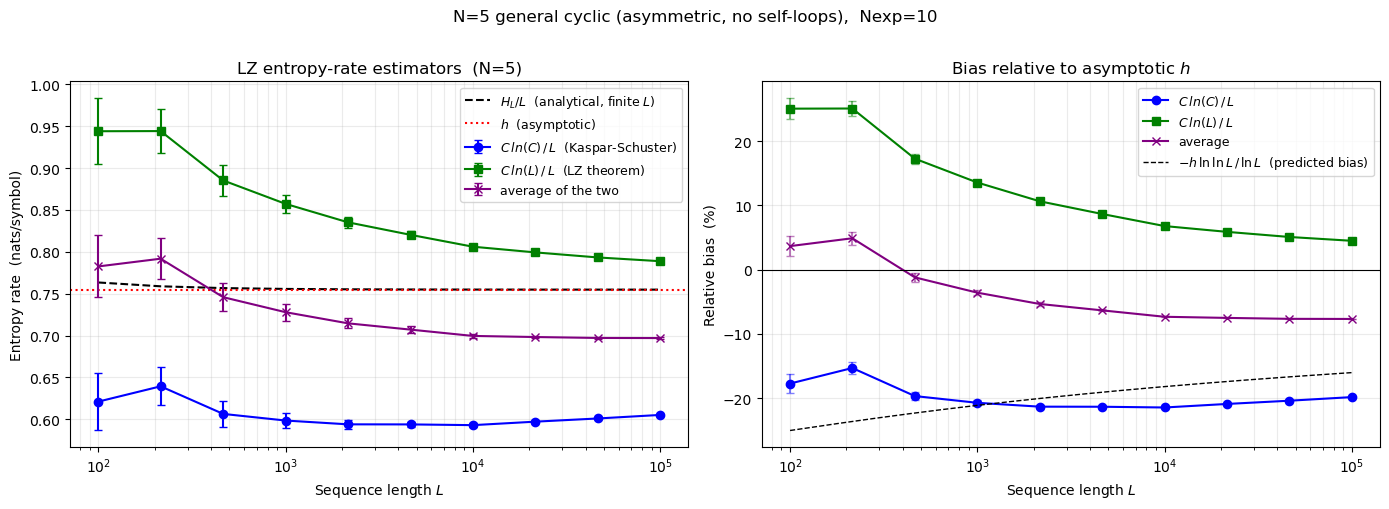

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

h_logC_mean  = np.mean(h_logC,     axis=1)
h_logC_std   = np.std(h_logC,      axis=1) / np.sqrt(Nexp)
h_logL_mean  = np.mean(h_logL,     axis=1)
h_logL_std   = np.std(h_logL,      axis=1) / np.sqrt(Nexp)
h_logCL_mean = np.mean(h_logCL_av, axis=1)
h_logCL_std  = np.std(h_logCL_av,  axis=1) / np.sqrt(Nexp)

marker_list = ['o-', 's-', '^-', 'd-', 'x-']
log_lbl     = 'log$_2$' if use_log2 else 'ln'
h_unit      = 'bits/symbol' if use_log2 else 'nats/symbol'

# ---- panel 1: estimates vs analytical ----
ax = axes[0]
ax.plot(L_list, h_L, 'k--', lw=1.5,  label=r'$H_L/L$  (analytical, finite $L$)')
ax.axhline(h_ana, color='r', ls=':',  lw=1.5, label=r'$h$  (asymptotic)')
ax.errorbar(L_list, h_logC_mean,  yerr=h_logC_std,
            fmt=marker_list[0], color='blue',   capsize=3,
            label=rf'$C\,{log_lbl}(C)\,/\,L$  (Kaspar-Schuster)')
ax.errorbar(L_list, h_logL_mean,  yerr=h_logL_std,
            fmt=marker_list[1], color='green',  capsize=3,
            label=rf'$C\,{log_lbl}(L)\,/\,L$  (LZ theorem)')
ax.errorbar(L_list, h_logCL_mean, yerr=h_logCL_std,
            fmt=marker_list[4], color='purple', capsize=3,
            label=r'average of the two')
if include_LZ78:
    h_logC78_mean  = np.mean(h_logC78,     axis=1)
    h_logC78_std   = np.std(h_logC78,      axis=1) / np.sqrt(Nexp)
    h_logL78_mean  = np.mean(h_logL78,     axis=1)
    h_logL78_std   = np.std(h_logL78,      axis=1) / np.sqrt(Nexp)
    ax.errorbar(L_list, h_logC78_mean, yerr=h_logC78_std,
                fmt=marker_list[2], color='cornflowerblue', capsize=3,
                label=rf'$C\,{log_lbl}(C)\,/\,L$  (LZ78)')
    ax.errorbar(L_list, h_logL78_mean, yerr=h_logL78_std,
                fmt=marker_list[3], color='lightgreen',     capsize=3,
                label=rf'$C\,{log_lbl}(L)\,/\,L$  (LZ78)')
ax.set_xscale('log')
ax.set_xlabel('Sequence length $L$')
ax.set_ylabel(f'Entropy rate  ({h_unit})')
ax.set_title(f'LZ entropy-rate estimators  (N={N})')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.25)

# ---- panel 2: relative bias (%) ----
ax = axes[1]
L_fine    = np.logspace(np.log10(L_list[0]), np.log10(L_list[-1]), 200)
bias_pred = -h_ana * np.log(np.log(L_fine)) / np.log(L_fine) * 100

ax.plot(L_list, (h_logC_mean  - h_ana) / h_ana * 100,
        marker_list[0], color='blue',   label=rf'$C\,{log_lbl}(C)\,/\,L$')

ax.plot(L_list, (h_logL_mean  - h_ana) / h_ana * 100,
        marker_list[1], color='green',  label=rf'$C\,{log_lbl}(L)\,/\,L$')
ax.plot(L_list, (h_logCL_mean - h_ana) / h_ana * 100,
        marker_list[4], color='purple', label='average')

# also plot as error bars to show variance, even though bias is the main focus here
ax.errorbar(L_list, (h_logC_mean  - h_ana) / h_ana * 100, yerr=h_logC_std / h_ana * 100 / np.sqrt(Nexp),
            fmt='none', ecolor='blue', alpha=0.5, capsize=3)
ax.errorbar(L_list, (h_logL_mean  - h_ana) / h_ana * 100, yerr=h_logL_std / h_ana * 100 / np.sqrt(Nexp),
            fmt='none', ecolor='green', alpha=0.5, capsize=3)
ax.errorbar(L_list, (h_logCL_mean - h_ana) / h_ana * 100, yerr=h_logCL_std / h_ana * 100 / np.sqrt(Nexp),
            fmt='none', ecolor='purple', alpha=0.5, capsize=3)

if include_LZ78:
    ax.plot(L_list, (h_logC78_mean - h_ana) / h_ana * 100,
            marker_list[2], color='cornflowerblue', label=rf'$C\,{log_lbl}(C)\,/\,L$  (LZ78)')
    ax.plot(L_list, (h_logL78_mean - h_ana) / h_ana * 100,
            marker_list[3], color='lightgreen',     label=rf'$C\,{log_lbl}(L)\,/\,L$  (LZ78)')
ax.plot(L_fine, bias_pred, 'k--', lw=1,
        label=r'$-h\,\ln\ln L\,/\,\ln L$  (predicted bias)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Sequence length $L$')
ax.set_ylabel('Relative bias  (%)')
ax.set_title('Bias relative to asymptotic $h$')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.25)

fig.suptitle(rf'{model_label},  Nexp={Nexp}', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## SCRAP...

In [56]:
LL=len(markov_seq_target)
alpha=3
c77= lz77(markov_seq_target)
c78 = lz78(markov_seq_target)
np.log(c77) * c77 / LL, np.log(c78) * c78 / LL / np.log(alpha),c77 * np.log(LL) / LL, c78 * np.log(LL) / LL, entropy_rate_ana(p)

(0.13008641788341396,
 0.2741090535175776,
 0.20067029085443108,
 0.4224092353097577,
 0.19851524334587267)

In [61]:
hrate_upper(c77, LL, alpha, log2=True), hrate_upper(c78, LL, alpha, log2=True)

(0.14693021477210153, 0.33404798857845397)

In [59]:
def hrate_upper(complexity, L, Nstates, log2=False):
    if log2:
        log_func = np.log2
    else:
        log_func = np.log
    hest_upper = (complexity + 1) / (L * log_func(Nstates)) * log_func(2 * Nstates * (complexity + 1))
    return hest_upper

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

h_logC_mean = np.mean(h_logC, axis=1)
h_logC_std  = np.std(h_logC,  axis=1)
h_logL_mean = np.mean(h_logL, axis=1)
h_logL_std  = np.std(h_logL,  axis=1)

# ---- panel 1: estimates vs analytical ----
ax = axes[0]
ax.plot(L_list, h_L, 'k--', lw=1.5,  label=r'$H_L/L$  (analytical, finite $L$)')
ax.axhline(h_ana, color='r', ls=':',  lw=1.5, label=r'$h$  (asymptotic)')
ax.errorbar(L_list, h_logC_mean, yerr=h_logC_std,
            fmt='o-', capsize=3, label=r'$C\ln C\,/\,L$  (Kaspar-Schuster)')
ax.errorbar(L_list, h_logL_mean, yerr=h_logL_std,
            fmt='s-', capsize=3, label=r'$C\ln L\,/\,L$  (LZ theorem)')
ax.set_xscale('log')
ax.set_xlabel('Sequence length $L$')
ax.set_ylabel('Entropy rate  (nats / symbol)')
ax.set_title(f'LZ entropy-rate estimators  (N={N})')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.25)

# ---- panel 2: relative bias (%) ----
ax = axes[1]
# predicted bias of C log C / L:  -h * ln(ln L) / ln L
L_fine   = np.logspace(np.log10(L_list[0]), np.log10(L_list[-1]), 200)
bias_pred = -h_ana * np.log(np.log(L_fine)) / np.log(L_fine) * 100

ax.plot(L_list,
        (h_logC_mean - h_ana) / h_ana * 100,
        'o-', label=r'$C\ln C\,/\,L$  (measured)')
ax.plot(L_list,
        (h_logL_mean - h_ana) / h_ana * 100,
        's-', label=r'$C\ln L\,/\,L$  (measured)')
ax.plot(L_fine, bias_pred, 'k--', lw=1,
        label=r'$-h\,\ln\ln L\,/\,\ln L$  (predicted bias of $C\ln C/L$)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Sequence length $L$')
ax.set_ylabel('Relative bias  (%)')
ax.set_title('Bias relative to asymptotic $h$')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.25)

fig.suptitle(
    rf'N={N}-state cyclic Markov,  $p$={np.round(p_vec,2)},  Nexp={Nexp}',
    y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## Why the estimate gives ~0.48 instead of ~0.62 at L=10⁵–10⁶

Both `C·log(C)/L` and `C·log(L)/L` are asymptotically consistent estimators of h (they both → h as L→∞), because `C ~ L·h/log(L)` implies `log(C) ~ log(L)` asymptotically.

**The real issue is extremely slow convergence.**

The bias of `C·log(C)/L` relative to h is:

$$\frac{C\log C}{L} \approx h \cdot \frac{\log C}{\log L} = h \cdot \left(1 - \frac{\log\log L}{\log L} + \frac{\log h}{\log L}\right)$$

The leading correction term $-h\cdot\log(\log L)/\log L$ decays very slowly. For $L=10^6$, $h=0.611$:

- $C \approx L\cdot h/\log L \approx 44{,}200$, so $\log C \approx 10.7$, $\log L \approx 13.8$
- Predicted: $\approx 0.611 \times 10.7/13.8 \approx \mathbf{0.473}$ — matches the observed ~0.48

The estimate is **not** converging to 0.48; it is very slowly increasing toward 0.611 from below. The convergence rate is $O(\log\log L / \log L)$, which requires astronomically large $L$ to be negligible.

`C·log(L)/L` overshoots in the other direction (≈ 0.789 at L=10⁶). Neither estimator is fast-converging at accessible sequence lengths.